# general knowledge

### downloading data

In [1]:
import pandas as pd

In [50]:
ds = pd.read_csv("../data/data (2).csv")

In [3]:
ds.sample(4)

,x,y,z
1118,286,327.600006,a
2795,543,96.600006,b
616,205,385.600006,a
382,619,172.600006,a


### understanding data

In [4]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3221 entries, 0 to 3220
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       3221 non-null   int64  
 1   y       3221 non-null   float64
 2   z       3221 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 75.6+ KB


In [5]:
ds.describe()

,x,y
count,3221.000000,3221.000000
mean,380.838870,253.389512
std,158.816977,115.608309
min,23.000000,4.600006
25%,243.000000,163.600006
50%,412.000000,251.600006
75%,512.000000,351.600006
max,693.000000,496.600002


In [51]:
ds['x'] = ds['x'].astype(float)

In [52]:
target_dict = {
    'a': 0,
    'b': 1,
}
ds['z'] = ds['z'].map(target_dict)

In [8]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3221 entries, 0 to 3220
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       3221 non-null   float64
 1   y       3221 non-null   float64
 2   z       3221 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 75.6 KB


In [9]:
ds.describe()

,x,y,z
count,3221.000000,3221.000000,3221.000000
mean,380.838870,253.389512,0.496430
std,158.816977,115.608309,0.500065
min,23.000000,4.600006,0.000000
25%,243.000000,163.600006,0.000000
50%,412.000000,251.600006,0.000000
75%,512.000000,351.600006,1.000000
max,693.000000,496.600002,1.000000


In [10]:
ds['z'].value_counts()

z
0    1622
1    1599
Name: count, dtype: int64

so our data samples are balanced

<Axes: >

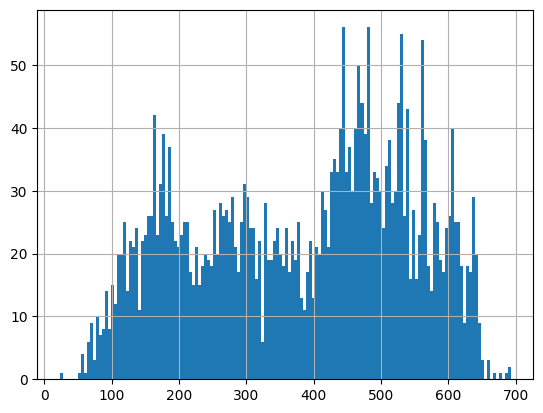

In [11]:
ds['x'].hist(bins=150)

<Axes: >

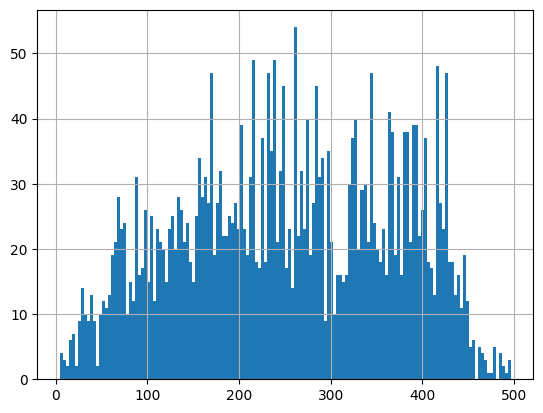

In [12]:
ds['y'].hist(bins=150)

In [13]:
import matplotlib.pyplot as plt 
import seaborn as sns

<Axes: >

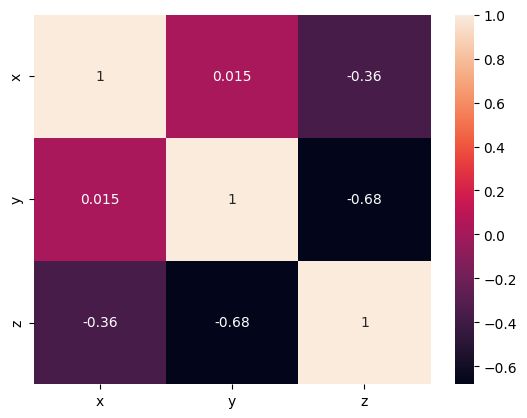

In [14]:
sns.heatmap(ds.corr(), annot=True)

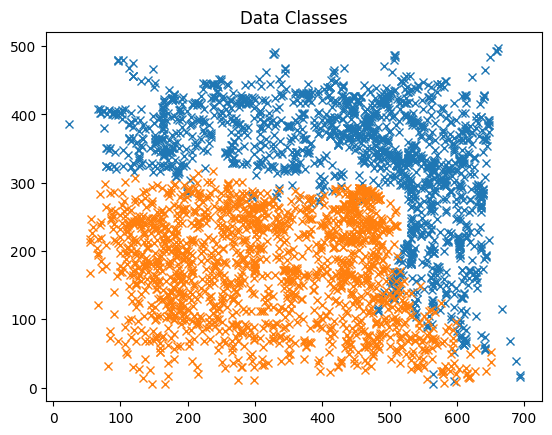

In [15]:
fig, ax = plt.subplots()

ax.plot(ds[ds['z'] == 0]['x'], ds[ds['z'] == 0]['y'], 'x')
ax.plot(ds[ds['z'] == 1]['x'], ds[ds['z'] == 1]['y'], 'x')

plt.title('Data Classes')
plt.show()

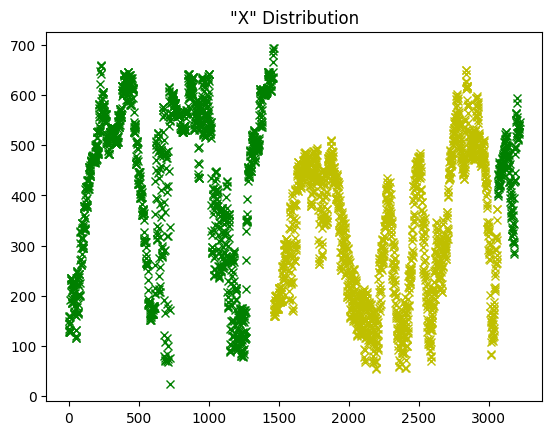

In [16]:
fig, ax = plt.subplots()

ax.plot(ds[ds['z'] == 0]['x'], 'x', c='g')
ax.plot(ds[ds['z'] == 1]['x'], 'x', c='y')

plt.title('"X" Distribution')
plt.show()

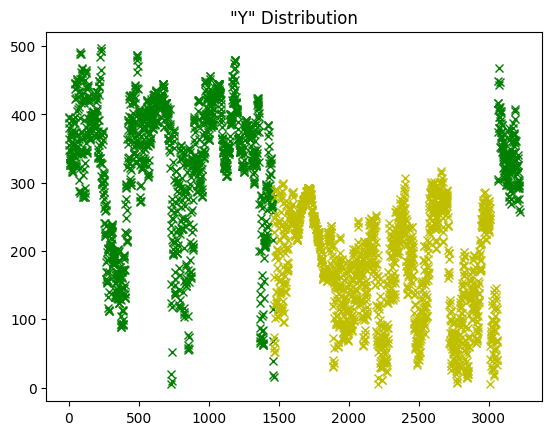

In [17]:
fig, ax = plt.subplots()

ax.plot(ds[ds['z'] == 0]['y'], 'x', c='g')
ax.plot(ds[ds['z'] == 1]['y'], 'x', c='y')

plt.title('"Y" Distribution')
plt.show()

it looks like one of our classes may be represented via concrete range

let's develop baseline model

In [53]:
X = ds.drop(["z"], axis=1)
y = ds["z"]

In [19]:
from sklearn.metrics import f1_score, classification_report

In [20]:
import numpy as np

def baseline_model(X) -> int:
    if (X[0] in range(50, 500)) or (X[1] in range(0, 300)):
        return 1
    else:
        return 0

In [21]:
preds = np.array([baseline_model(x) for x in X.values])

In [22]:
print(classification_report(y, preds, zero_division=np.nan))

              precision    recall  f1-score   support

           0       0.84      0.47      0.60      1622
           1       0.63      0.91      0.74      1599

    accuracy                           0.69      3221
   macro avg       0.74      0.69      0.67      3221
weighted avg       0.74      0.69      0.67      3221



we've seen the results let's move on

## building models

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
len(X_train), len(y_train), len(X_test), len(y_test)

(2415, 2415, 806, 806)

In [55]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    penalty=None,
    fit_intercept=True,
    max_iter=100,
    random_state=42
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88       429
           1       0.85      0.88      0.86       377

    accuracy                           0.87       806
   macro avg       0.87      0.87      0.87       806
weighted avg       0.87      0.87      0.87       806



In [25]:
from sklearn.model_selection import FixedThresholdClassifier

lrf_model = FixedThresholdClassifier(lr_model, threshold=0.55)
lrf_model.fit(X_train, y_train)
y_pred_lrf = lrf_model.predict(X_test)
print(classification_report(y_test, y_pred_lrf))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88       429
           1       0.86      0.86      0.86       377

    accuracy                           0.87       806
   macro avg       0.87      0.87      0.87       806
weighted avg       0.87      0.87      0.87       806



### confusion matrix

In [26]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_lr, labels=[0, 1])

array([[371,  58],
       [ 46, 331]], dtype=int64)

In [27]:
from sklearn.linear_model import LogisticRegressionCV

lrcv_model = LogisticRegressionCV(
    penalty='l2',
    cv=12,
)
lrcv_model.fit(X_train, y_train)
y_pred_lrcv = lrcv_model.predict(X_test)
print(classification_report(y_test, y_pred_lrcv))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88       429
           1       0.85      0.88      0.86       377

    accuracy                           0.87       806
   macro avg       0.87      0.87      0.87       806
weighted avg       0.87      0.87      0.87       806



## KNN

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsClassifier(
    n_neighbors=11,
)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       429
           1       0.97      0.97      0.97       377

    accuracy                           0.97       806
   macro avg       0.97      0.97      0.97       806
weighted avg       0.97      0.97      0.97       806



In [29]:
confusion_matrix(y_test, y_pred_knn, labels=[0, 1])

array([[417,  12],
       [ 12, 365]], dtype=int64)

### cross-validation

In [30]:
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold

kf = KFold(n_splits=5)
scores_knn = cross_val_score(knn_model, X_train_scaled, y_train, cv=kf, scoring='f1') 
print(f"K-Folds: {scores_knn}")
print(f"K-Fold Accuracy: {scores_knn.mean():.2f}")

K-Folds: [0.97959184 0.95918367 0.97265625 0.95934959 0.97468354]
K-Fold Accuracy: 0.97


## Decision Trees

In [31]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=15
)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       429
           1       0.98      0.97      0.97       377

    accuracy                           0.98       806
   macro avg       0.98      0.98      0.98       806
weighted avg       0.98      0.98      0.98       806



[Text(0.5, 0.875, 'x[1] <= 294.1\ngini = 0.5\nsamples = 2415\nvalue = [1193, 1222]'), Text(0.25, 0.625, 'x[0] <= 502.5\ngini = 0.316\nsamples = 1505\nvalue = [296, 1209]'), Text(0.375, 0.75, 'True  '), Text(0.125, 0.375, 'x[1] <= 271.1\ngini = 0.04\nsamples = 1136\nvalue = [23, 1113]'), Text(0.0625, 0.125, '\n  (...)  \n'), Text(0.1875, 0.125, '\n  (...)  \n'), Text(0.375, 0.375, 'x[1] <= 116.1\ngini = 0.385\nsamples = 369\nvalue = [273.0, 96.0]'), Text(0.3125, 0.125, '\n  (...)  \n'), Text(0.4375, 0.125, '\n  (...)  \n'), Text(0.75, 0.625, 'x[1] <= 302.1\ngini = 0.028\nsamples = 910\nvalue = [897, 13]'), Text(0.625, 0.75, '  False'), Text(0.625, 0.375, 'x[0] <= 318.0\ngini = 0.364\nsamples = 46\nvalue = [35, 11]'), Text(0.5625, 0.125, '\n  (...)  \n'), Text(0.6875, 0.125, '\n  (...)  \n'), Text(0.875, 0.375, 'x[1] <= 314.1\ngini = 0.005\nsamples = 864\nvalue = [862, 2]'), Text(0.8125, 0.125, '\n  (...)  \n'), Text(0.9375, 0.125, '\n  (...)  \n')]


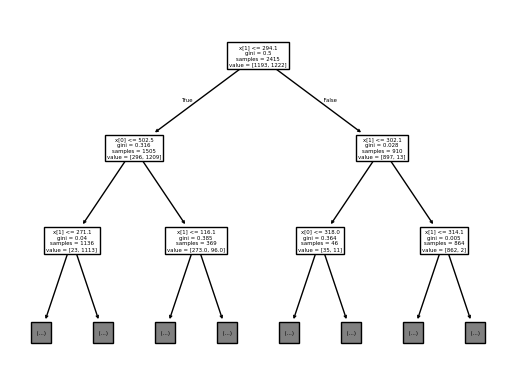

In [32]:
print(tree.plot_tree(tree_model, max_depth=2))

## Naive Bayes

In [33]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB(
    
)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       429
           1       0.87      0.89      0.88       377

    accuracy                           0.89       806
   macro avg       0.89      0.89      0.89       806
weighted avg       0.89      0.89      0.89       806



In [34]:
ds = pd.read_csv('../data/emails.csv')

In [35]:
test_prompt = ds[ds['spam'] == 0].iloc[24]['text']

In [36]:
X = ds.drop(["spam"], axis=1)
y = ds["spam"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(y_train), len(X_test), len(y_test)

(4582, 4582, 1146, 1146)

In [38]:
train_corpus = [email[0] for email in X_train.values]
train_corpus[90]

'Subject: phone interview  shirley ,  please , arrange a phone interview next week . tt , sg , zl , vk .  vince  - - - - - - - - - - - - - - - - - - - - - - forwarded by vince j kaminski / hou / ect on 11 / 21 / 2000  08 : 46 am - - - - - - - - - - - - - - - - - - - - - - - - - - -  nina knirel on 11 / 20 / 2000 05 : 13 : 47 pm  to : vince . j . kaminski @ enron . com  cc :  subject :  708 graham place # 207  austin , tx 78705  november 20 , 2000  dear mr . kaminski :  i read with interest your company \x01 , s description on the  web page . i was highly impressed by the work that  enron corporation does and would like to inquire about  employment opportunities with your company .  enclosed is a copy of my resume that details my  academic qualifications and practical experience . i am  excited about stepping into a position , which will  utilize my technical , analytical , and interpersonal  skills in a fast paced environment , and look forward  to expanding my horizons with new challe

In [39]:
test_corpus = [email[0] for email in X_test.values]
test_corpus[90]

'Subject: perfect logo charset = koi 8 - r " >  thinking of breathing new life into your business ?  start from revamping its front - end - logo and visuai identity .  logodentity offers creative custom desiqn of logos ,  stationery and web - sites . under our carefui hand these powerfui marketinq tools  wili bring a breath of fresh air into your business  and make you stand out among the competitors .  you are just a ciick  away from your future success . ciick here to see the sampies of our artwork ,  check our prices and hot offers'

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    
)
X_train_v = vectorizer.fit_transform(train_corpus).toarray()
X_test_v = vectorizer.transform(test_corpus).toarray()

In [41]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_v, y_train)
y_pred_nb = nb_model.predict(X_test_v)
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91       856
           1       1.00      0.41      0.59       290

    accuracy                           0.85      1146
   macro avg       0.92      0.71      0.75      1146
weighted avg       0.88      0.85      0.83      1146



In [42]:
prompt = "Hello, I'd like to inform you this is a correct address, please inform me of the following "
prompt = vectorizer.transform([prompt]).toarray()

nb_model.predict(prompt)

array([0], dtype=int64)

## PCA

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_train_scaled)

PCA(n_components=2)

In [44]:
print(pca.explained_variance_ratio_)

[0.50801486 0.49198514]


In [45]:
X_pca = pca.transform(X_test_scaled)

In [46]:
x = [sample[0] for sample in X_pca]
y = [sample[1] for sample in X_pca]

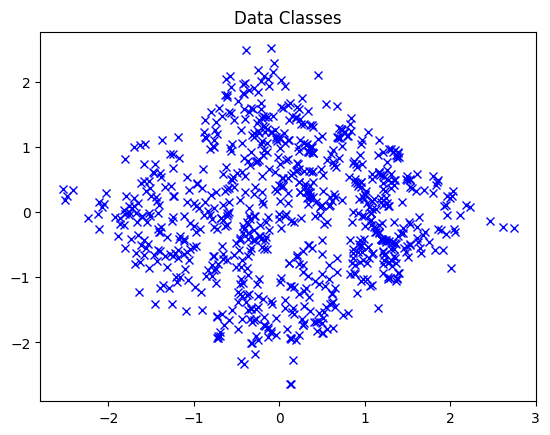

In [47]:
fig, ax = plt.subplots()

ax.plot(x, y, 'bx')

plt.title('Data Classes')
plt.show()

In [48]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    eta=0.1,
    max_depth=2,
)

xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_xgb))

XGBoostError: [13:08:49] C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\data\data.cc:508: Check failed: this->labels.Size() % this->num_row_ == 0 (2167 vs. 0) : Incorrect size for labels.

## Ensembles

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    
)
rf_model.fit(X_train, y_train)
y_preds_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_preds_rf))

ValueError: could not convert string to float: 'Subject: re : request for payroll reclassification - approved  joann ,  yes , sorry . 413 was the number on the form i received .  vince  enron property & services corp .  from : joann holloway 01 / 11 / 2000 02 : 01 pm  to : vince j kaminski / hou / ect @ ect  cc :  subject : re : request for payroll reclassification - approved  vince ,  on your reclass information , the company number indicated should be 0011 not  413 .  jo ann holloway  x 35957  vince j kaminski  01 / 11 / 2000 01 : 33 pm  to : stella l ely / hou / ect @ ect  cc : jeff kinneman / hou / ect @ ect , carmen chavira / hou / ect @ ect , michelle  hargrave / hou / ect @ ect , stephen wolfe / hou / ect @ ect , michael s  galvan / hou / ect @ ect , gary mccumber / hou / ect @ ect , billie  akhave / epsc / hou / ect @ ect , joann holloway / epsc / hou / ect @ ect , louis  allen / epsc / hou / ect @ ect , bradley stewart / hou / ect @ ect , carol coats / hou / ect @ ect  subject

In [56]:
from sklearn.ensemble import AdaBoostClassifier

ab_model = AdaBoostClassifier(
    estimator=rf_model,
    n_estimators=50,
)
ab_model.fit(X_train, y_train)
y_preds_ab = ab_model.predict(X_test)
print(classification_report(y_test, y_preds_ab))

c:\Users\Omen\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.97      0.98       429
           1       0.97      0.98      0.98       377

    accuracy                           0.98       806
   macro avg       0.98      0.98      0.98       806
weighted avg       0.98      0.98      0.98       806



In [57]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=50,
)
gb_model.fit(X_train, y_train)
y_preds_gb = gb_model.predict(X_test)
print(classification_report(y_test, y_preds_gb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       429
           1       0.97      0.97      0.97       377

    accuracy                           0.98       806
   macro avg       0.98      0.98      0.98       806
weighted avg       0.98      0.98      0.98       806



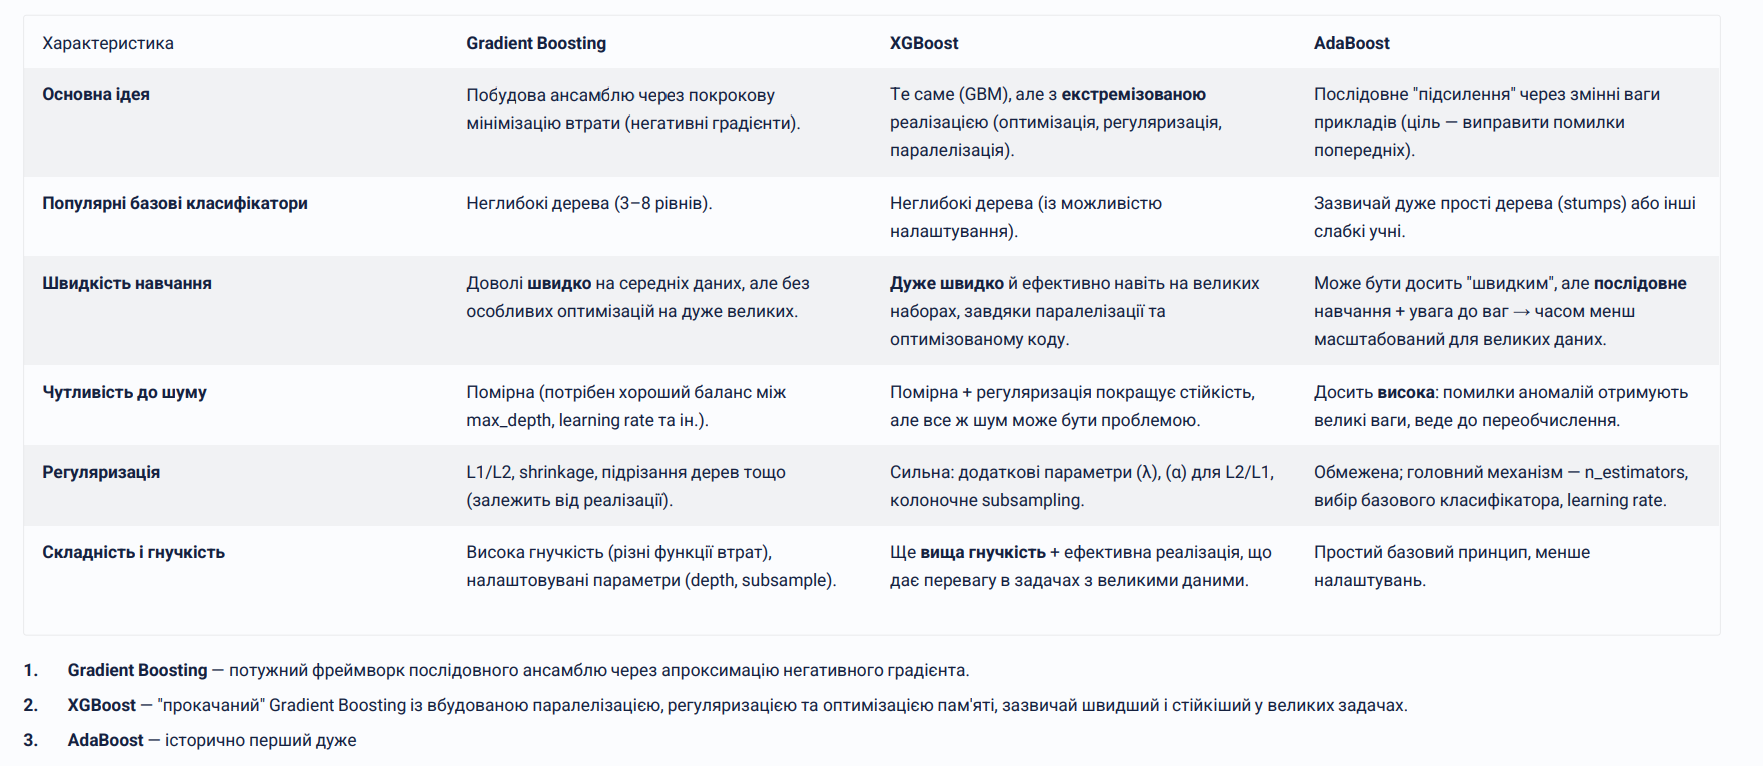

### stacking

In [58]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC

substack_model = StackingClassifier(
    estimators=[
        ("tree", DecisionTreeClassifier()),
        ("knn", KNeighborsClassifier()),
    ],
    final_estimator=LogisticRegression(penalty="l2",),
    cv=3,
)

stacking_model = StackingClassifier(
    estimators=[
        ("knn", KNeighborsClassifier(n_neighbors=10,)),
        ("substack", substack_model),
        ("rf", RandomForestClassifier())
    ],
    final_estimator=LogisticRegression(penalty=None,),
    cv=5,
)
stacking_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('knn', KNeighborsClassifier(n_neighbors=10)),
                               ('substack',
                                StackingClassifier(cv=3,
                                                   estimators=[('tree',
                                                                DecisionTreeClassifier()),
                                                               ('knn',
                                                                KNeighborsClassifier())],
                                                   final_estimator=LogisticRegression())),
                               ('rf', RandomForestClassifier())],
                   final_estimator=LogisticRegression(penalty=None))

In [59]:
y_preds_stacking = stacking_model.predict(X_test)
print(classification_report(y_test, y_preds_stacking))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       429
           1       0.97      0.98      0.97       377

    accuracy                           0.98       806
   macro avg       0.98      0.98      0.98       806
weighted avg       0.98      0.98      0.98       806



In [62]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

# Learn to predict each class against the other
classifier = OneVsRestClassifier(
    SVC(kernel='linear', probability=True, random_state=42)
)
y_score = classifier.fit(X_train, y_train).decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(2):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot of a ROC curve for a specific class
plt.figure()
plt.plot(fpr[2], tpr[2], label='ROC curve (area = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

# Plot ROC curve
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]))
for i in range(2):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                   ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()

KeyError: 'key of type tuple not found and not a MultiIndex'

## calibration

In [63]:
from sklearn.calibration import CalibratedClassifierCV

calibration_model = CalibratedClassifierCV(
    estimator=KNeighborsClassifier(),
    cv=5,
)
calibration_model.fit(X_train, y_train)
y_preds_calibrated = calibration_model.predict(X_test)
print(classification_report(y_test, y_preds_calibrated))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       429
           1       0.98      0.97      0.97       377

    accuracy                           0.97       806
   macro avg       0.97      0.97      0.97       806
weighted avg       0.97      0.97      0.97       806

